In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

from sc_exp_design.data import DataManager


In [2]:
ADATA_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/gdrive/ds_HID01_logicle_100k_UMAP_ann.h5ad"


In [3]:
adata = sc.read_h5ad(ADATA_PATH)
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap'
    obsm: 'X_pca', 'X_umap'
    layers: 'positives', 'raw'
    

In [4]:
EXPERIMENTAL_COLUMNS = [
    'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]',
    'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]',
    'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'o2_[%]'
]
len(EXPERIMENTAL_COLUMNS)


13

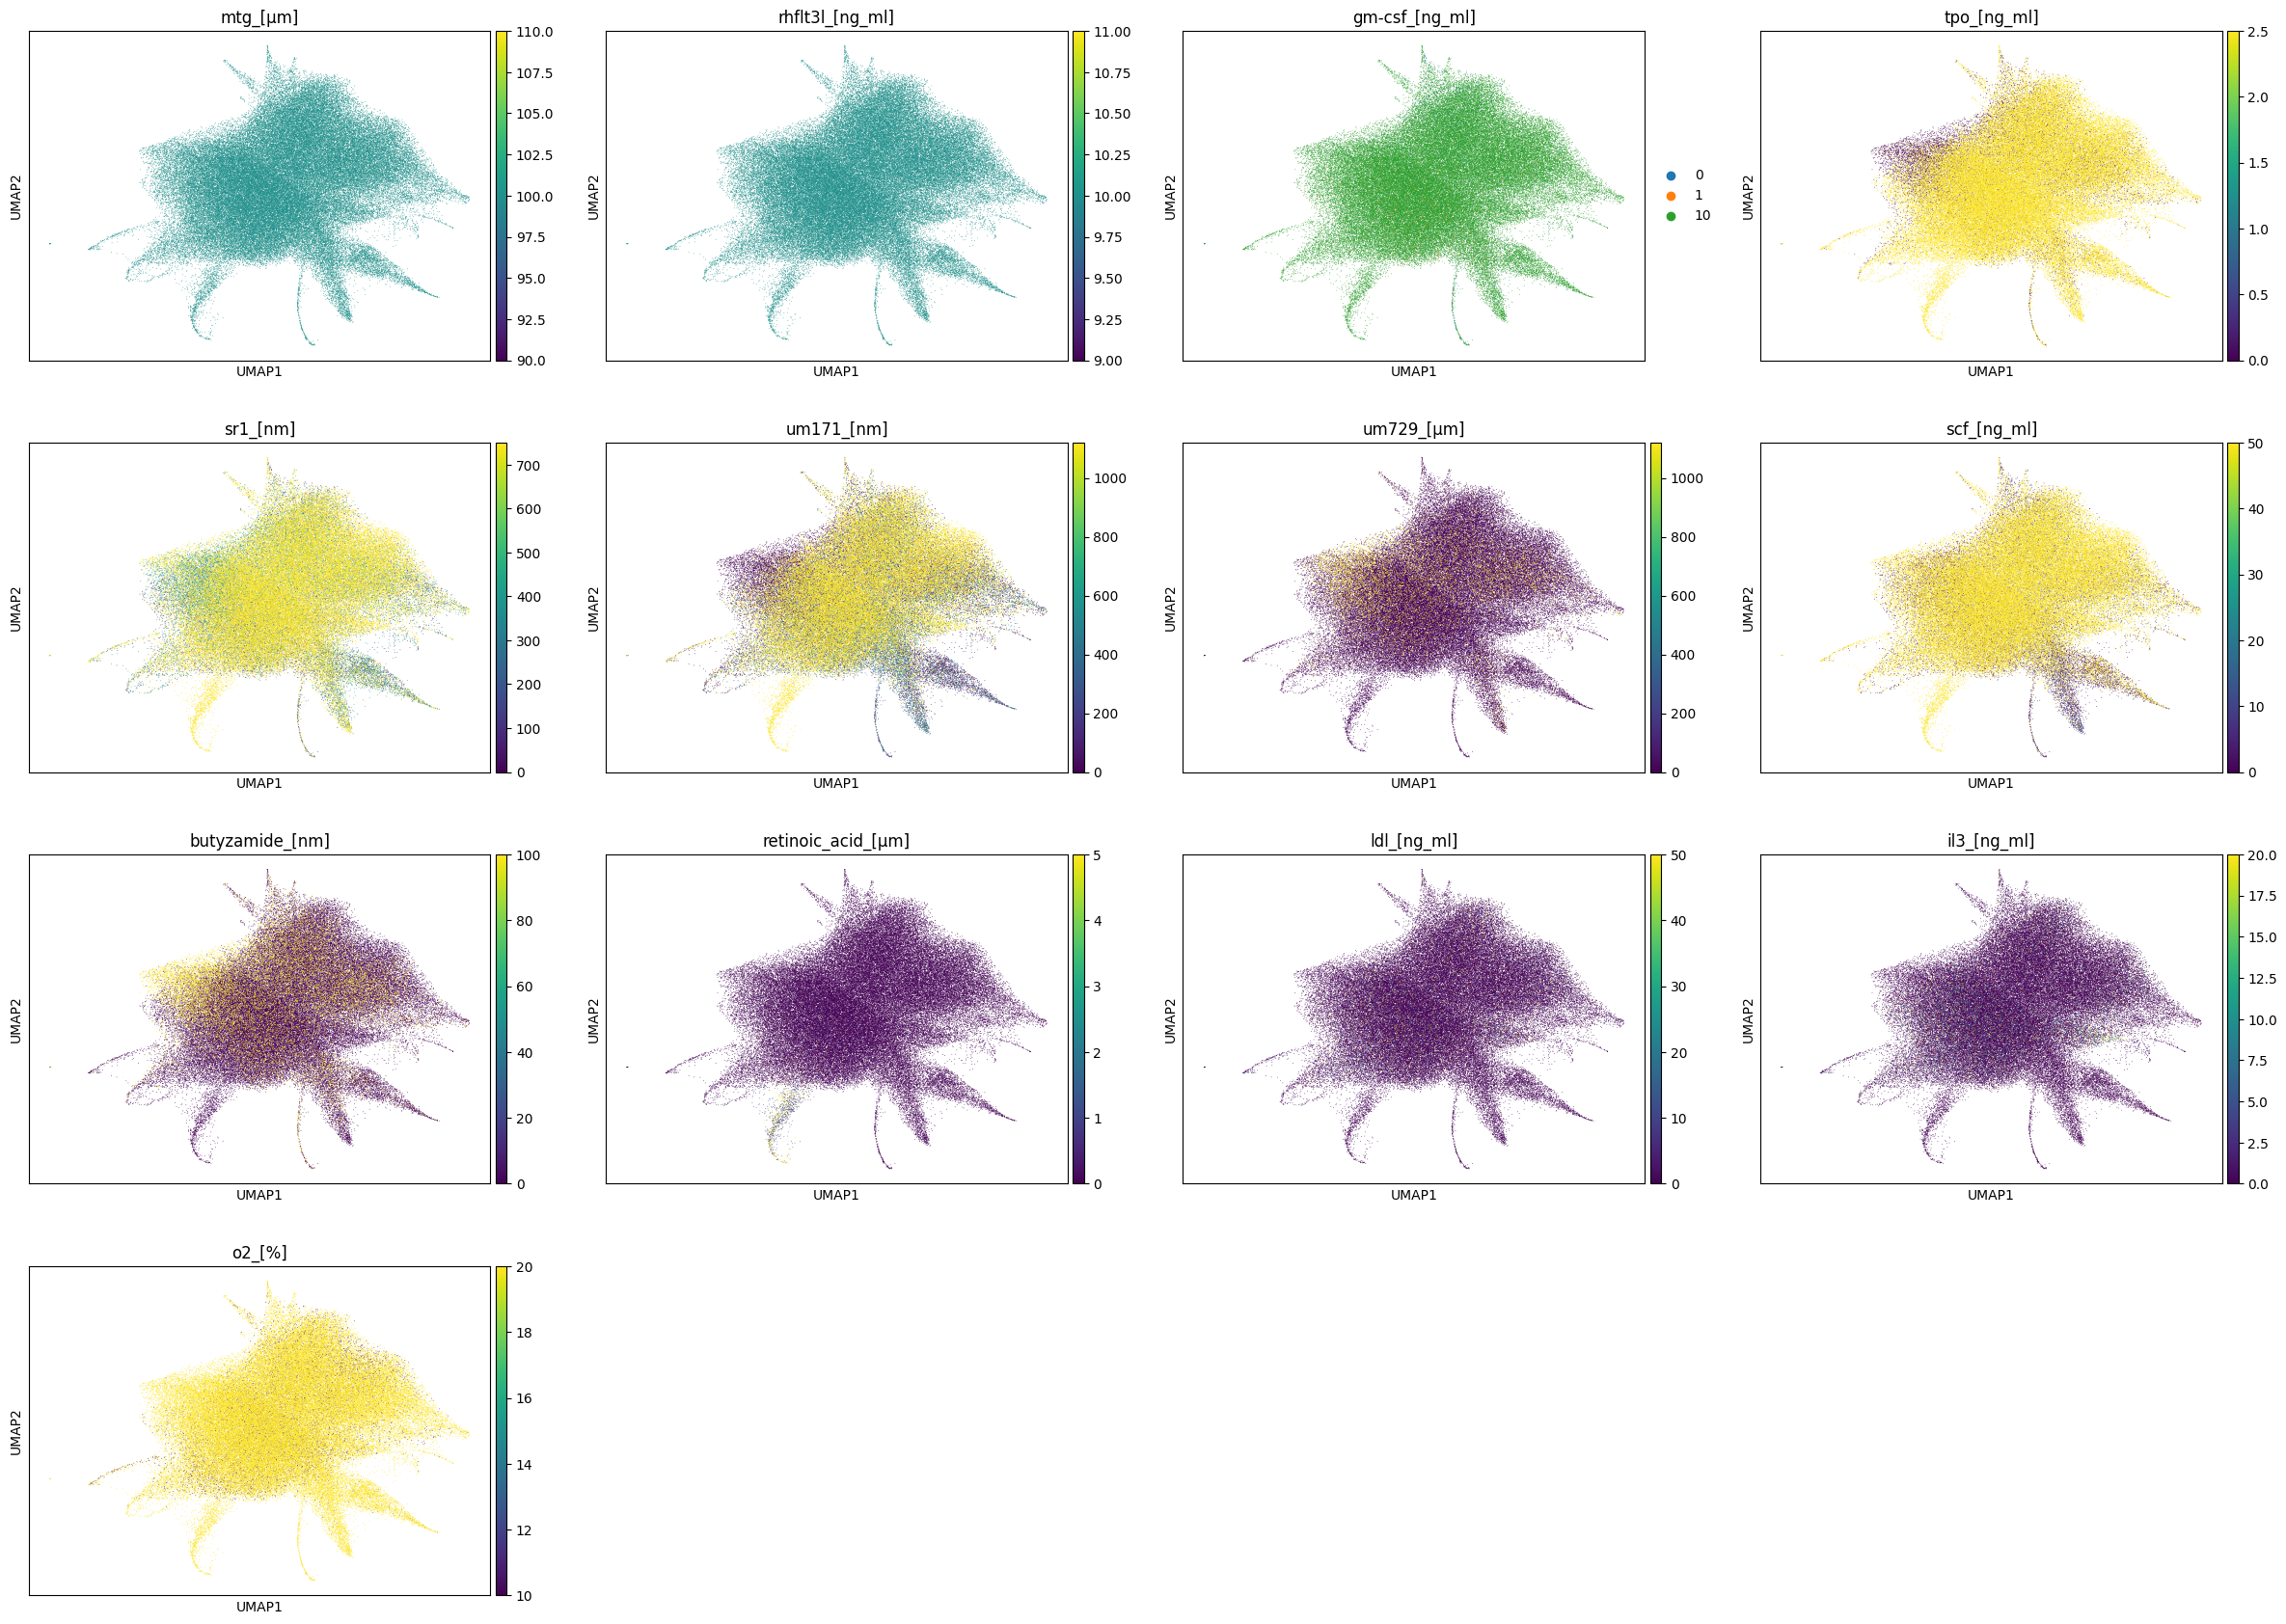

In [5]:
sc.pl.embedding(adata, "umap", color=EXPERIMENTAL_COLUMNS)


In [6]:
LOG1P_EXP_COL = ["um171_[nm]", "um729_[µm]", "scf_[ng_ml]", 
                 "butyzamide_[nm]", "o2_[%]",
                 "sr1_[nm]", "mtg_[µm]", "rhflt3l_[ng_ml]", "gm-csf_[ng_ml]"]
LOG21P_EXP_COL = ["ldl_[ng_ml]", 
    "il3_[ng_ml]", "retinoic_acid_[µm]",
]
for column in EXPERIMENTAL_COLUMNS:
    if isinstance(adata.obs[column].values.dtype, pd.CategoricalDtype):
        adata.obs[column] = adata.obs[column].astype(float)
    
    print(column, adata.obs[column].dtype)
    # print("\t", adata.obs[column].nunique())
    print("\t", adata.obs[column].unique())
    if column in LOG1P_EXP_COL:
        print("\tlog1p", np.log1p(adata.obs[column]).unique())
    if column in LOG21P_EXP_COL:
        print("\tlog2", np.log2(adata.obs[column] + 1).unique())


mtg_[µm] int64
	 [100]
	log1p [4.61512052]
rhflt3l_[ng_ml] int64
	 [10]
	log1p [2.39789527]
gm-csf_[ng_ml] float64
	 [10.  0.  1.]
	log1p [2.39789527 0.         0.69314718]
tpo_[ng_ml] float64
	 [2.5  0.   0.5  1.   0.25]
sr1_[nm] int64
	 [750 375  75   0]
	log1p [6.62140565 5.92958914 4.33073334 0.        ]
um171_[nm] float64
	 [1120.     1.5  280.     0.   560.    70. ]
	log1p [7.02197642 0.91629073 5.63835467 0.         6.32972091 4.26267988]
um729_[µm] float64
	 [0.00e+00 1.12e+03 7.50e-01 1.50e+00]
	log1p [0.         7.02197642 0.55961579 0.91629073]
scf_[ng_ml] int64
	 [50 10  0]
	log1p [3.93182563 2.39789527 0.        ]
butyzamide_[nm] int64
	 [  0 100]
	log1p [0.         4.61512052]
retinoic_acid_[µm] int64
	 [0 1 5]
	log2 [0.        1.        2.5849625]
ldl_[ng_ml] int64
	 [ 0  2 50 10  5 20]
	log2 [0.         1.5849625  5.67242534 3.45943162 2.5849625  4.39231742]
il3_[ng_ml] float64
	 [ 5.   0.  10.   2.5 20. ]
	log2 [2.5849625  0.         3.45943162 1.80735492 4.39231742]
o

In [ ]:
def get_log_transformed_experimental_variables(
    adata,
    EXPERIMENTAL_COLUMNS,
    LOG1P_EXP_COL,
    LOG21P_EXP_COL,
    obsm_col="cond_concat",
):
    for column in EXPERIMENTAL_COLUMNS:
        if isinstance(adata.obs[column].values.dtype, pd.CategoricalDtype):
            adata.obs[column] = adata.obs[column].astype(float)
        
        if column in LOG1P_EXP_COL:
            adata.obsm[column] = np.log1p(adata.obs[column]).values[:, None]
        elif column in LOG21P_EXP_COL:
            adata.obsm[column] = np.log2(adata.obs[column] + 1).values[:, None]
        else:
            adata.obsm[column] = adata.obs[column].values[:, None]
    adata.obsm[obsm_col] = np.concatenate(
        [adata.obsm[col] for col in EXPERIMENTAL_COLUMNS], axis=-1
    )
    return adata


In [8]:
adata = get_log_transformed_experimental_variables(
    adata,
    EXPERIMENTAL_COLUMNS,
    LOG1P_EXP_COL,
    LOG21P_EXP_COL
)


In [9]:
adata


AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'gm-csf_[ng_ml]_colors'
    obsm: 'X_pca', 'X_umap', 'mtg_[µm]

In [10]:
datamanager = DataManager(
    adata,
    sample_rep=None,
    control_key=None,
    perturbations=EXPERIMENTAL_COLUMNS,
    perturbations_in_obsm=EXPERIMENTAL_COLUMNS,
    perturbation_reps={e:e for e in EXPERIMENTAL_COLUMNS},
)
data = datamanager.get_data()


In [11]:
data.perturbation_data


{'feats_mtg_[µm]_mtg_[µm]': array([[4.61512052],
        [4.61512052],
        [4.61512052],
        ...,
        [4.61512052],
        [4.61512052],
        [4.61512052]]),
 'feats_rhflt3l_[ng_ml]_rhflt3l_[ng_ml]': array([[2.39789527],
        [2.39789527],
        [2.39789527],
        ...,
        [2.39789527],
        [2.39789527],
        [2.39789527]]),
 'feats_gm-csf_[ng_ml]_gm-csf_[ng_ml]': array([[2.39789527],
        [2.39789527],
        [2.39789527],
        ...,
        [2.39789527],
        [2.39789527],
        [2.39789527]]),
 'feats_tpo_[ng_ml]_tpo_[ng_ml]': array([[2.5],
        [2.5],
        [2.5],
        ...,
        [2.5],
        [2.5],
        [2.5]]),
 'feats_sr1_[nm]_sr1_[nm]': array([[6.62140565],
        [6.62140565],
        [6.62140565],
        ...,
        [6.62140565],
        [6.62140565],
        [4.33073334]]),
 'feats_um171_[nm]_um171_[nm]': array([[7.02197642],
        [7.02197642],
        [7.02197642],
        ...,
        [6.32972091],
        

### Visualize Densities along for channel features.

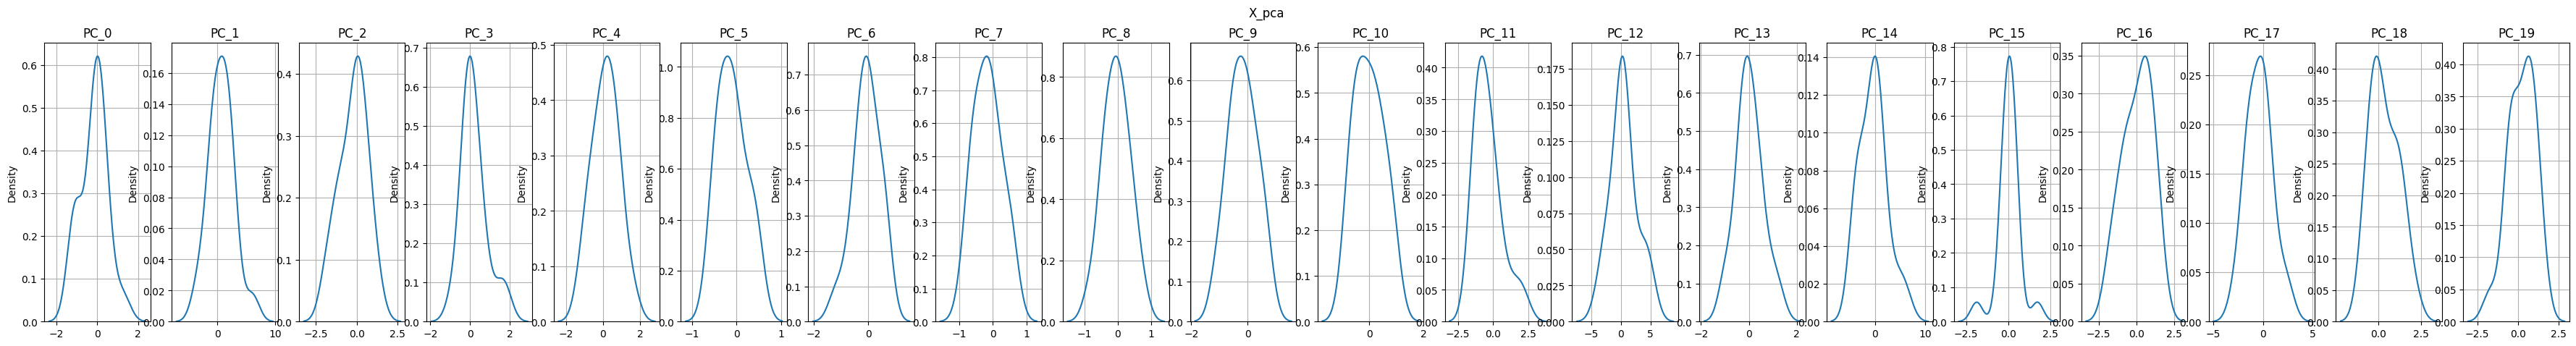

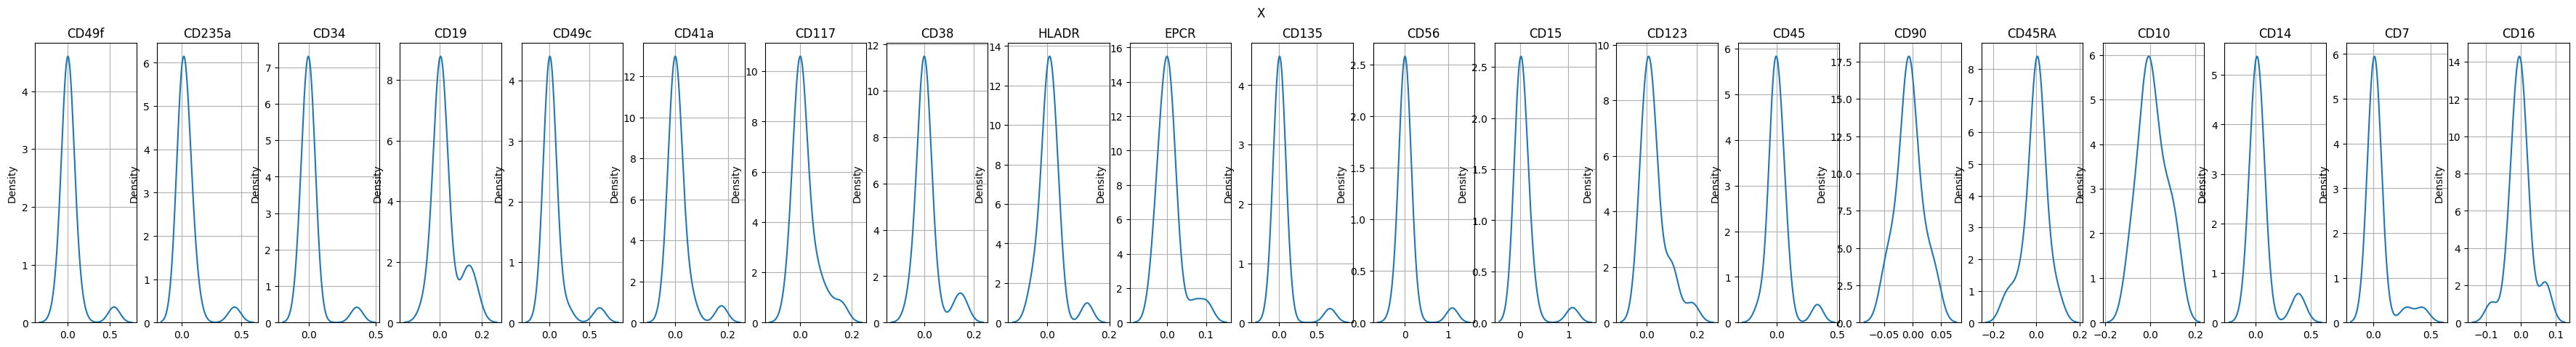

In [12]:
int2antibody = {
    idx: adata.var.iloc[idx][["antibody"]].values[0] for idx in range(adata.var.shape[0])
}
antibody2idx = {v:k for k, v in int2antibody.items()}

data = adata.obsm["X_pca"]
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("X_pca")
for idx in range(data.shape[1]):
    antibody = f"PC_{idx}"#int2antibody[idx]
    sns.kdeplot(data[idx], ax=axes[idx])
    axes[idx].grid(True)
    axes[idx].set_title(antibody)

data = adata.X
fig, axes = plt.subplots(1, data.shape[1], figsize=(45, 5))
fig.suptitle("X")
for idx in range(data.shape[1]):
    antibody = int2antibody[idx]
    sns.kdeplot(data[idx], ax=axes[idx])
    axes[idx].grid(True)
    axes[idx].set_title(antibody)
